# F1 Race Data Analysis
**Martin Adebayo · Magd Aref · Johann Cubillo**

Data: [Formula 1 Race Dataset (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)

---
## Table of contents
1. [Setup & data loading](#setup)
2. [Data cleaning](#cleaning)
3. [Pit stop strategy](#pit-stops)
4. [Circuit clustering](#clustering)
5. [Grid vs finishing position](#grid-finish)
6. [Race result predictor (ML)](#ml)
7. [Constructor standings](#constructors)
8. [Driver careers](#careers)
9. [Lap time trends](#lap-times)
10. [Qualifying improvement](#qualifying)
11. [Lap 1 analysis](#lap1)
12. [Summary](#summary)


---
## 1. Setup & data loading 


In [ ]:
# Libraries 
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt 
import seaborn as sns             
import warnings
warnings.filterwarnings('ignore')


plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False})

results       = pd.read_csv('results.csv')
races         = pd.read_csv('races.csv')
drivers       = pd.read_csv('drivers.csv')
constructors  = pd.read_csv('constructors.csv')
circuits      = pd.read_csv('circuits.csv')
status        = pd.read_csv('status.csv')
standings     = pd.read_csv('driver_standings.csv')
con_standings = pd.read_csv('constructor_standings.csv')
pit_stops     = pd.read_csv('pit_stops.csv')
lap_times     = pd.read_csv('lap_times.csv')

print(f"results: {len(results):,} rows")
print(f"lap_times: {len(lap_times):,} rows")


results: 27,304 rows
lap_times: 618,766 rows


In [96]:
df = results.copy()

# Add year, round, and circuit information from the races table
df = df.merge(races[['raceId', 'year', 'round', 'circuitId']], on='raceId')

# Add driver name
df = df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
df['driver'] = df['forename'] + ' ' + df['surname']

# Add team (constructor) name
df = df.merge(constructors[['constructorId', 'name']], on='constructorId')

# Add retirement reason (status)
df = df.merge(status[['statusId', 'status']], on='statusId')

# Convert columns that should be numbers
for col in ['grid', 'positionOrder', 'points']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create a full-name column for the constructor
df = df.rename(columns={'name': 'team'})


# DNF = Did Not Finish. Cars that are "lapped" (+1 Lap etc.) did finish — only
# mechanical failures and crashes count as DNFs.
lapped   = df['status'].str.startswith('+')   # e.g. "+1 Lap"
finished = df['statusId'] == 1                 # "Finished"
df['dnf']    = (~(finished | lapped)).astype(int)   # 1 = retired, 0 = finished
df['win']    = (df['positionOrder'] == 1).astype(int)
df['podium'] = (df['positionOrder'] <= 3).astype(int)

# keep rows where the driver actually started from the grid
base = df[df['grid'] > 0].copy()
base['pos_change'] = base['grid'] - base['positionOrder']  # positive = gained places

print(f"Working table: {len(base):,} race starts")
print(base[['driver', 'team', 'year', 'grid', 'positionOrder', 'pos_change', 'dnf']].head())


Working table: 25,646 race starts
              driver        team  year  grid  positionOrder  pos_change  dnf
0     Lewis Hamilton     McLaren  2008   1.0              1         0.0    0
1      Nick Heidfeld  BMW Sauber  2008   5.0              2         3.0    0
2       Nico Rosberg    Williams  2008   7.0              3         4.0    0
3    Fernando Alonso     Renault  2008  11.0              4         7.0    0
4  Heikki Kovalainen     McLaren  2008   3.0              5        -2.0    0


---
## 2. Data cleaning 


In [97]:
print(results.dtypes)
print()

CSV_NULL = '\\N'

print("Null values:")
for col in results.columns:
    n = (results[col] == CSV_NULL).sum()

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                object
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
dtype: object

Null values:


In [98]:
# Identfying Null values

results      = pd.read_csv('results.csv',     na_values=CSV_NULL)
races        = pd.read_csv('races.csv',       na_values=CSV_NULL)
drivers      = pd.read_csv('drivers.csv',     na_values=CSV_NULL)
constructors = pd.read_csv('constructors.csv',na_values=CSV_NULL)
circuits     = pd.read_csv('circuits.csv',    na_values=CSV_NULL)
status       = pd.read_csv('status.csv',      na_values=CSV_NULL)
qualifying   = pd.read_csv('qualifying.csv',  na_values=CSV_NULL)
pit_stops    = pd.read_csv('pit_stops.csv',   na_values=CSV_NULL)
lap_times    = pd.read_csv('lap_times.csv',   na_values=CSV_NULL)

# Verify: the '\\N' values should now show up as NaN
missing = results.isnull().sum()
missing = missing[missing > 0]
#The 'position' column has " + missing['position'] + " missing values — these are DNFs
print(missing)

number                 6
grid                  20
position           10953
time               19252
milliseconds       19252
fastestLap         18535
rank               18277
fastestLapTime     18535
fastestLapSpeed    19052
dtype: int64


In [99]:
# Convert the columns we need
for col in ['grid', 'positionOrder', 'points', 'laps']:
    results[col] = pd.to_numeric(results[col], errors='coerce')

# pit_stops milliseconds is also stored as text
pit_stops['milliseconds'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

In [100]:
# Outlier removal: lap times slower than 150% of the race median are not

min_lap = lap_times['milliseconds'].min() / 1000
max_lap = lap_times['milliseconds'].max() / 1000
slow_lap_count = (lap_times['milliseconds'] > 300_000).sum()
worst = lap_times.nlargest(3, 'milliseconds')[['raceId', 'driverId', 'lap', 'milliseconds']]
worst['seconds'] = worst['milliseconds'] / 1000

race_median = lap_times.groupby('raceId')['milliseconds'].median().rename('race_med')
lap_times = lap_times.drop(columns=['race_med'], errors='ignore').join(race_median, on='raceId')
lap_times_clean = lap_times[
    lap_times['milliseconds'] < lap_times['race_med'] * 1.50
].copy()

removed = len(lap_times) - len(lap_times_clean)
pct_removed = removed / len(lap_times) * 100
kept = len(lap_times_clean)

print(
f"""Lap time range: {min_lap:.1f}s – {max_lap:.1f}s
Laps over 5 min: {slow_lap_count:,}
Top 3 slowest:
{worst.to_string(index=False)}
Removed (>150% median): {removed:,} ({pct_removed:.2f}%) | Kept: {kept:,}
"""
)


Lap time range: 55.4s – 7507.5s
Laps over 5 min: 710
Top 3 slowest:
 raceId  driverId  lap  milliseconds  seconds
    847         2   25       7507547 7507.547
    847        13   25       7506656 7506.656
    847       808   25       7506243 7506.243
Removed (>150% median): 12,498 (2.02%) | Kept: 606,268



In [101]:
# Invaild Rows — grid position = 0

# Results table show some drivers have grid = 0.
# This means they started from the pit lane (outside the normal grid),
grid_zero = results[results['grid'] == 0]
grid_zero_with_status = grid_zero.merge(status, on='statusId')

In [102]:
# A duplicate row means the same driver appears twice in the same race —
# which shouldn't happen. These usually come from pre-qualifying in older
# seasons where a driver made multiple attempts. Keep only the first entry.

results = results.drop_duplicates(subset=['raceId', 'driverId'], keep='first')

---
## 3. Pit stop strategy

**Question:** Does the number of pit stops affect how many places a driver gains or loses?

We use **position change** (starting grid − finishing position) as our outcome.  
A positive number means the driver moved forward; negative means they fell back.

We test three common strategies: 1-stop, 2-stop, and 3+ stops.


In [103]:
# Summarise pit stop data per driver per race
pit_stops['ms_num'] = pd.to_numeric(pit_stops['milliseconds'], errors='coerce')

pit_summary = (
    pit_stops
    .groupby(['raceId', 'driverId'])
    .agg(
        num_stops    = ('stop', 'count'),        # how many stops?
        avg_pit_ms   = ('ms_num', 'mean'),        # average stop duration
        first_stop_lap = ('lap', 'min')           # which lap was the first stop?
    )
    .reset_index()
)

# merge pit info onto our main table
df_pit = base.merge(pit_summary, on=['raceId', 'driverId'], how='left')

# Label each driver's strategy
df_pit['strategy'] = df_pit['num_stops'].map({
    1: '1-stop',
    2: '2-stop',
    3: '3+ stops'
})

# Strategy dristribution
ORDER    = ['1-stop', '2-stop', '3+ stops']
df_strat = df_pit[df_pit['strategy'].isin(ORDER)].copy()

print(df_strat['strategy'].value_counts())
print()
print(df_strat.groupby('strategy')['pos_change'].mean())
print()
print("A two stop strategy yields a 1.21 place gain on average, compared to .44 for a one stop strategy.")

strategy
2-stop      5022
1-stop      3716
3+ stops    1899
Name: count, dtype: int64

strategy
1-stop      0.441335
2-stop      1.213262
3+ stops    0.586098
Name: pos_change, dtype: float64

A two stop strategy yields a 1.21 place gain on average, compared to .44 for a one stop strategy.


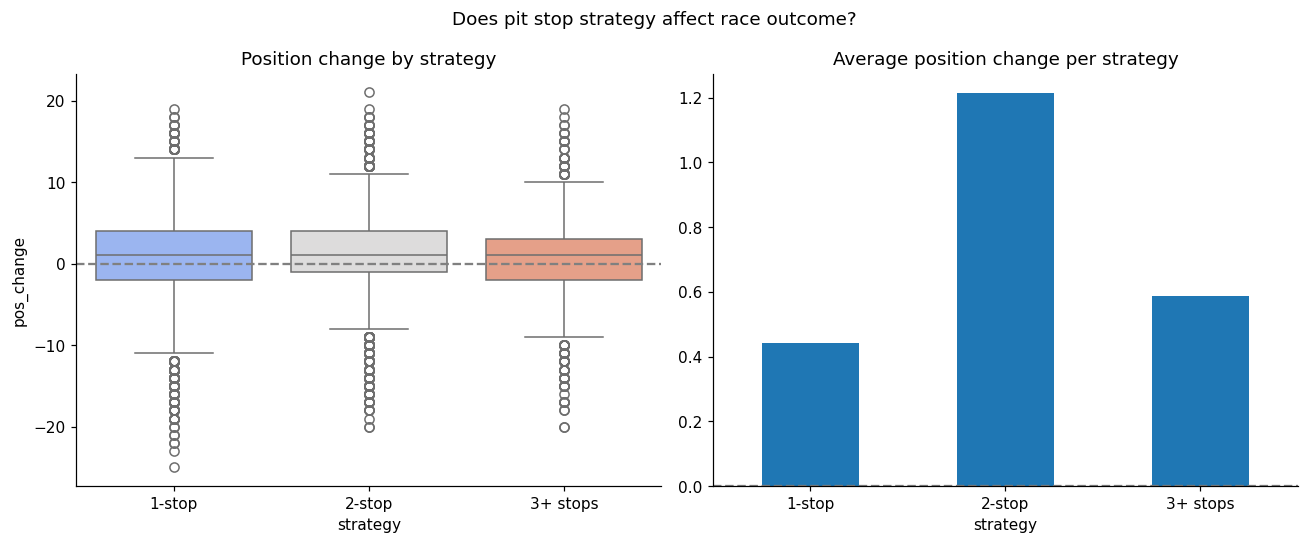

In [104]:
# Graph position change by strategy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Does pit stop strategy affect race outcome?')

sns.boxplot(data=df_strat, x='strategy', y='pos_change',
            order=ORDER, palette='coolwarm', ax=axes[0])
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].set_title('Position change by strategy')

avg = df_strat.groupby('strategy')['pos_change'].mean().reindex(ORDER)
avg.plot.bar(ax=axes[1], rot=0)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Average position change per strategy')

plt.tight_layout()
plt.show()


---
## 4. Circuit clustering 

**Question:** Can we group F1 circuits into types based on how races tend to play out?

**KMeans clustering** finds groups of similar items. We describe each circuit with three simple race stats and let the algorithm do the rest.

**Features used:**
- Average number of pit stops per driver (tyre wear / strategy)
- Average lap time (speed)
- DNF rate (how punishing the track is)


In [105]:
# Average lap time per circuit
lt = lap_times.merge(races[['raceId', 'year', 'circuitId']], on='raceId')
race_med = lt.groupby('raceId')['milliseconds'].median()
lt_clean = lt[lt['milliseconds'].between(
    race_med.loc[lt['raceId']].values * 0.8,
    race_med.loc[lt['raceId']].values * 1.5
)].copy()

lap_stats = (lt_clean
    .groupby('circuitId')['milliseconds']
    .mean()
    .reset_index(name='avg_lap_time'))

# Average pit stops per driver per circuit
pit_stats = (pit_stops
    .groupby(['raceId', 'driverId'])['stop']
    .count()
    .reset_index(name='num_stops')
    .merge(races[['raceId', 'circuitId']], on='raceId')
    .groupby('circuitId')['num_stops']
    .mean()
    .reset_index(name='avg_stops'))

# DNF rate per circuit
dnf_stats = (base
    .groupby('circuitId')['dnf']
    .mean()
    .reset_index(name='dnf_rate'))

# Merge all together
circ_feats = (circuits[['circuitId', 'name']]
    .merge(lap_stats, on='circuitId', how='left')
    .merge(pit_stats, on='circuitId', how='left')
    .merge(dnf_stats, on='circuitId', how='left')
    .dropna())

FEATURES = ['avg_lap_time', 'avg_stops', 'dnf_rate']
print(f'Circuits with complete data: {len(circ_feats)}')
print(circ_feats[FEATURES].describe().round(3))


Circuits with complete data: 41
       avg_lap_time  avg_stops  dnf_rate
count        41.000     41.000    41.000
mean      94088.697      1.979     0.309
std       10775.507      0.556     0.131
min       72991.956      1.182     0.050
25%       86417.785      1.711     0.173
50%       93373.230      1.956     0.347
75%      101506.549      2.163     0.425
max      116843.161      4.714     0.497


In [106]:
# Fit the final model k=3
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale features so each one carries equal weight
X = StandardScaler().fit_transform(circ_feats[FEATURES].values)


K_FINAL = 3
circ_feats['cluster'] = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10).fit_predict(X)


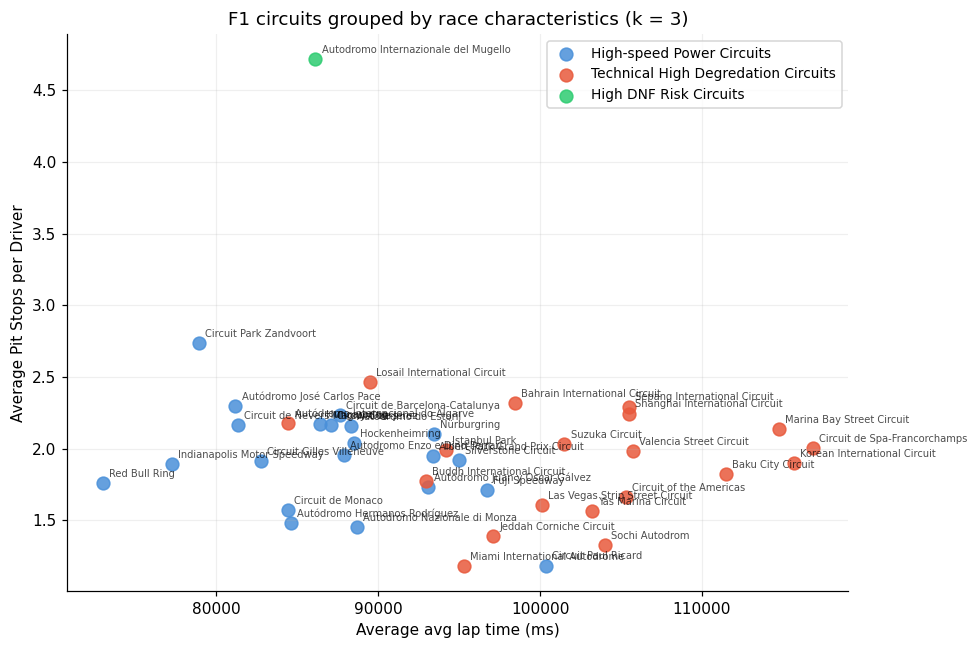

In [107]:
# Scatter: avg stops vs DNF rate 
CLUSTER_NAMES = {0: 'High-speed Power Circuits', 1: 'Technical High Degredation Circuits', 2: 'High DNF Risk Circuits'}
palette = ['#4A90D9', '#E8593C', '#2ECC71']

fig, ax = plt.subplots(figsize=(9, 6))
for c in range(K_FINAL):
    mask = circ_feats['cluster'] == c
    ax.scatter(
        circ_feats.loc[mask, 'avg_lap_time'],
        circ_feats.loc[mask, 'avg_stops'],
        s=70, label=CLUSTER_NAMES[c], color=palette[c], alpha=0.85
    )
    # Label each point with the circuit name
    for _, row in circ_feats[mask].iterrows():
        ax.annotate(row['name'], (row['avg_lap_time'], row['avg_stops']),
                    fontsize=6.5, alpha=0.7, xytext=(4, 4),
                    textcoords='offset points')

ax.set_xlabel('Average avg lap time (ms)')
ax.set_ylabel('Average Pit Stops per Driver')
ax.set_title(f'F1 circuits grouped by race characteristics (k = {K_FINAL})')
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## 5. Grid position vs finishing position

**Question:** How strongly does your qualifying position predict where you finish?

We calculate the **correlation** between grid and finishing position to find out.
We also look at how this has changed across different eras of the sport.


In [108]:
# Correlation between grid and finishing position
# Interpretation: moderate positive correlation — starting further back
# is associated with finishing further back.
corr = base['grid'].corr(base['positionOrder'])

print("Correlation (grid vs finish):", round(corr, 3))

# Pole position win rate
pole_races  = base[base['grid'] == 1]
pole_win_rt = (pole_races['positionOrder'] == 1).mean() * 100
print("Pole position -> race win:", round(pole_win_rt, 1), "% of the time")

# Podium rates by grid band
print()
print("Podium (top 3) rate by starting position:")
for label, lo, hi in [('P1-3', 1, 3), ('P4-6', 4, 6),
                       ('P7-10', 7, 10), ('P11-15', 11, 15), ('P16+', 16, 40)]:
    sub  = base[(base['grid'] >= lo) & (base['grid'] <= hi)]
    rate = (sub['positionOrder'] <= 3).mean() * 100
    print("  Grid " + label + ": " + str(round(rate, 1)) + "%")


Correlation (grid vs finish): 0.45
Pole position -> race win: 43.0 % of the time

Podium (top 3) rate by starting position:
  Grid P1-3: 55.6%
  Grid P4-6: 25.8%
  Grid P7-10: 9.1%
  Grid P11-15: 3.0%
  Grid P16+: 0.8%


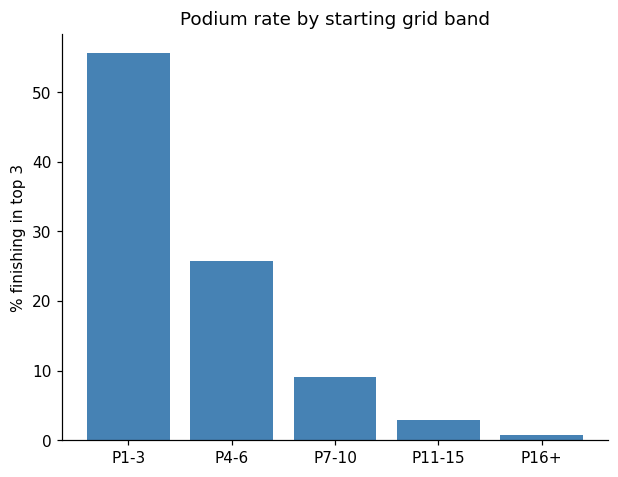

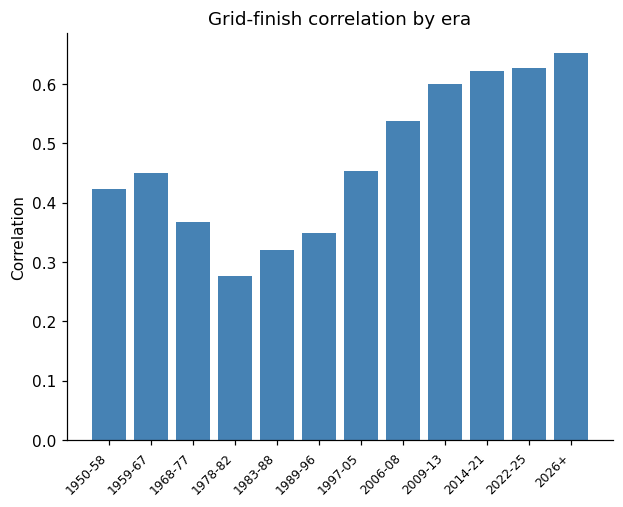

In [109]:
# Has the correlation changed over time?
era_bins   = [1949, 1958, 1966, 1976, 1981, 1987, 1995, 2004, 2007, 2012, 2020, 2024, 2030]
era_labels = ['1950-58', '1959-67', '1968-77', '1978-82', '1983-88',
              '1989-96', '1997-05', '2006-08', '2009-13', '2014-21', '2022-25', '2026+']
base['era'] = pd.cut(base['year'], bins=era_bins, labels=era_labels)

era_corr = (
    base.groupby('era', observed=True)
    .apply(lambda g: g['grid'].corr(g['positionOrder']))
    .reset_index()
)
era_corr.columns = ['era', 'correlation']

# Podium rate by grid band
bands  = ['P1-3', 'P4-6', 'P7-10', 'P11-15', 'P16+']
limits = [(1,3), (4,6), (7,10), (11,15), (16,40)]
rates  = [(base[(base['grid']>=lo)&(base['grid']<=hi)]['positionOrder']<=3).mean()*100
          for lo, hi in limits]

plt.bar(bands, rates, color='steelblue')
plt.title('Podium rate by starting grid band')
plt.ylabel('% finishing in top 3')
plt.show()

# Grid-finish correlation by era — has generally increased over time
plt.bar(era_corr['era'], era_corr['correlation'], color='steelblue')
plt.title('Grid-finish correlation by era')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.show()


---
## 6. Race result predictor (machine learning) <a id='ml'></a>

**Question:** Can we predict where a driver will finish using only information available before the race?

We train a **Decision Tree** using these features:
- Grid position (qualifying result)
- Past finishing position
- Drivers points so far

**Design choice:** We train on races from 2001–2019 and test on races from 2020 onwards.


In [129]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Driver standings: use points from the previous race
drv = (standings
       .merge(races[['raceId', 'year', 'round']], on='raceId')
       .sort_values(['driverId', 'year', 'round']))
drv['driver_pts_before'] = drv.groupby(['driverId', 'year'])['points'].shift(1).fillna(0)

# driver past performance: past finishing position
pos = (base[['raceId', 'driverId', 'year', 'round', 'positionOrder']]
               .sort_values(['driverId', 'year', 'round']))
pos['finish_pos_before'] = (pos   
                                    .groupby(['driverId', 'year'])['positionOrder']
                                    .shift(1).fillna(10))

# Merge features onto base table
df_ml = (base
         .merge(drv[['raceId', 'driverId', 'driver_pts_before']],
                on=['raceId', 'driverId'], how='left')
         .merge(pos[['raceId', 'driverId', 'finish_pos_before']],
                on=['raceId', 'driverId'], how='left'))

FEATURES = ['grid', 'driver_pts_before', 'finish_pos_before']
df_ml = df_ml[FEATURES + ['positionOrder', 'year']].dropna()

# Train/test split by year
train = df_ml[(df_ml['year'] > 1999) & (df_ml['year'] < 2020)]
test  = df_ml[df_ml['year'] >= 2020]

X_train, y_train = train[FEATURES].values, train['positionOrder'].values
X_test,  y_test  = test[FEATURES].values,  test['positionOrder'].values

print("Training rows:", len(X_train), " (races 1999-2019)")
print("Test rows:",     len(X_test),  " (races 2020+)")

Training rows: 7754  (races 1999-2019)
Test rows: 2607  (races 2020+)


In [130]:
# Fit decision tree
tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)

# Baseline: predict everyone finishes where they qualified
baseline_preds = test['grid'].values

# MAE = Mean Absolute Error (average positions off by)
# RMSE = Root Mean Squared Error (penalises large errors more)
tree_mae  = mean_absolute_error(y_test, tree_preds)
base_mae  = mean_absolute_error(y_test, baseline_preds)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_preds))
base_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))

print("Decision Tree  — MAE:", round(tree_mae, 2), " RMSE:", round(tree_rmse, 2))
print("Baseline (=grid) — MAE:", round(base_mae, 2), " RMSE:", round(base_rmse, 2))


Decision Tree  — MAE: 3.42  RMSE: 4.42
Baseline (=grid) — MAE: 3.43  RMSE: 4.95


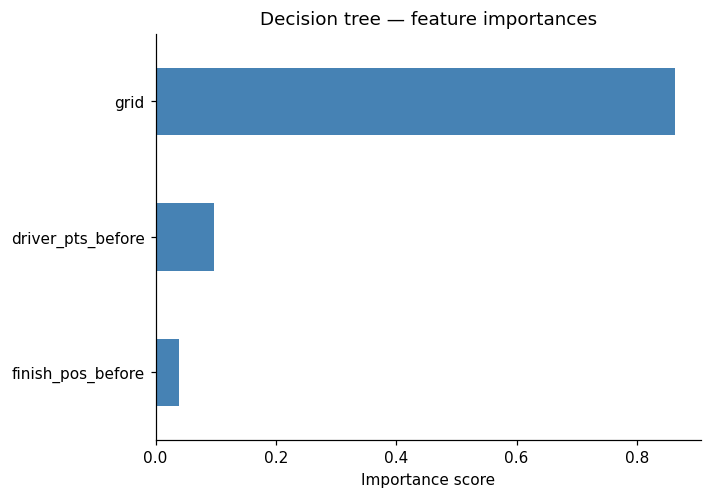

Most important features:
  grid: 0.863
  driver_pts_before: 0.097
  finish_pos_before: 0.04


In [112]:
# Which features matter most?
importances = pd.Series(tree.feature_importances_, index=FEATURES).sort_values()

importances.plot(kind='barh', color='steelblue')
plt.title('Decision tree — feature importances')
plt.xlabel('Importance score')
plt.show()

print("Most important features:")
for feat, imp in importances.sort_values(ascending=False).items():
    print("  " + feat + ": " + str(round(imp, 3)))


---
## 7. Constructor standings over time <a id='constructors'></a>

A visual of how the major constructor teams have risen and fallen since 1990.

We show:
1. A line chart of final championship points per season
2. A bump chart showing championship position round-by-round in 2023


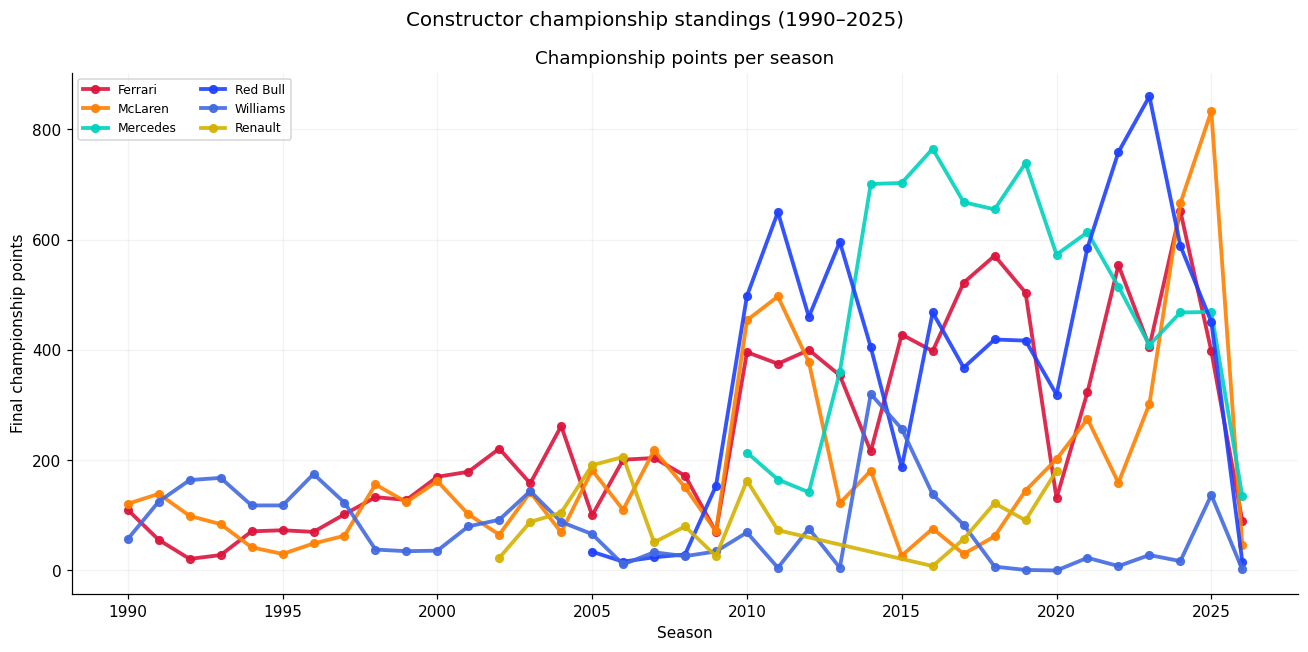

In [113]:
# Prepare constructor standings data
cs = (con_standings
      .merge(races[['raceId', 'year', 'round']], on='raceId')
      .merge(constructors[['constructorId', 'name']], on='constructorId'))
cs['points']   = pd.to_numeric(cs['points'],   errors='coerce')
cs['position'] = pd.to_numeric(cs['position'], errors='coerce')

# Final standings
final_cs = (cs[cs['year'] >= 1990]
            .sort_values('round')
            .groupby(['year', 'name'])
            .last()
            .reset_index())

# Focus on major teams
TEAMS = {
    'Ferrari':  '#DC143C', 'McLaren':  '#FF8000', 'Mercedes': '#00D2BE',
    'Red Bull': '#1E41FF', 'Williams': '#4169E1', 'Renault':  '#D4B200',
}
final_focus = final_cs[final_cs['name'].isin(TEAMS)][['year', 'name', 'points']]

# Line chart: championship points per season
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Constructor championship standings (1990–2025)', fontsize=13)

for team, color in TEAMS.items():
    td = final_focus[final_focus['name'] == team].sort_values('year')
    ax.plot(td['year'], td['points'], 'o-', label=team, color=color,
            linewidth=2.5, markersize=5, alpha=0.9)
ax.set_xlabel('Season')
ax.set_ylabel('Final championship points')
ax.set_title('Championship points per season')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


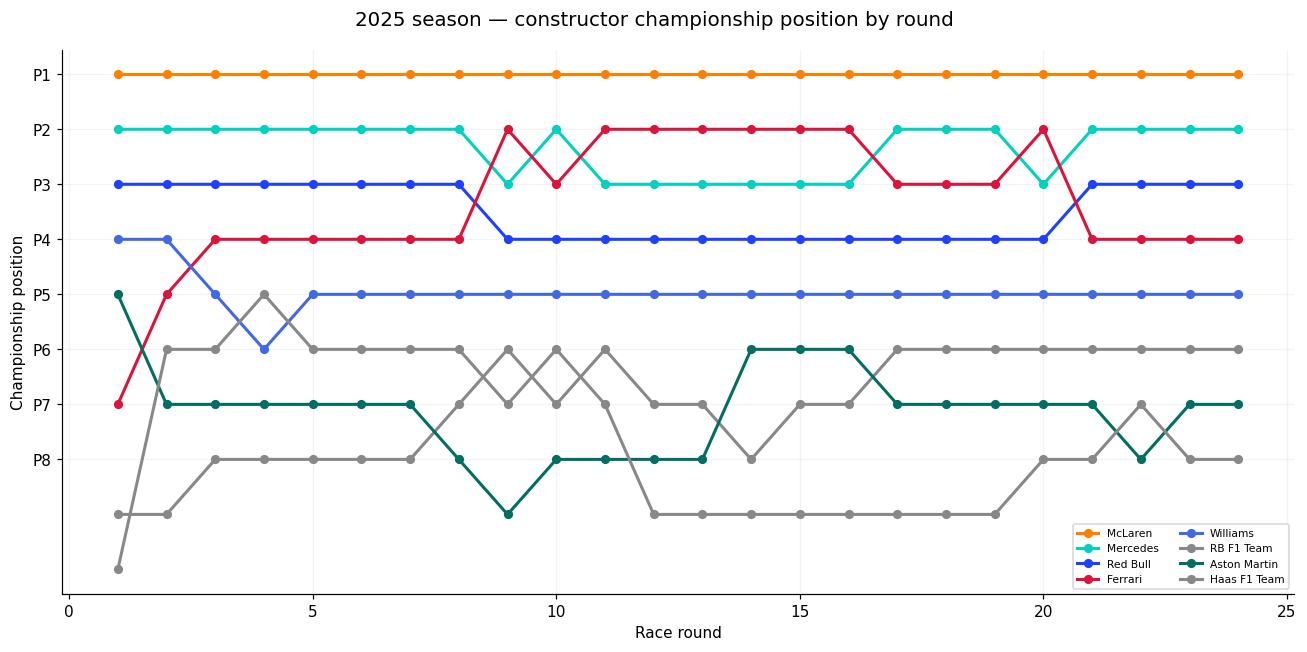

In [131]:
# Bump chart: 2023 season position by round
y23 = cs[cs['year'] == 2025].copy()
top8 = y23.groupby('name')['points'].max().nlargest(8).index.tolist()
y23t = y23[y23['name'].isin(top8)]

COLORS_23 = {'Red Bull':'#1E41FF','Mercedes':'#00D2BE','Ferrari':'#DC143C',
             'McLaren':'#FF8000','Aston Martin':'#006F62','Alpine F1 Team':'#0090FF',
             'Williams':'#4169E1','AlphaTauri':'#2B4562'}

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('2025 season — constructor championship position by round', fontsize=13)

for team in top8:
    td = y23t[y23t['name'] == team].sort_values('round')
    ax.plot(td['round'], td['position'], 'o-', label=team,
            color=COLORS_23.get(team, '#888'), linewidth=2, markersize=5)

ax.invert_yaxis()   # P1 at the top
ax.set_xlabel('Race round')
ax.set_ylabel('Championship position')
ax.set_yticks(range(1, 9))
ax.set_yticklabels([f'P{i}' for i in range(1, 9)])
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()


---
## 8. Driver career performance <a id='careers'></a>

**Question:** How do the greatest drivers of all time compare?

We use **win rate** (wins ÷ starts) so we can fairly compare drivers across eras.

We also look at:
- How performance changed throughout each driver's career
- Peak 3-season win rate (the best sustained period)
- Head-to-head results against their teammate


In [115]:
# Season over Season stats for Drivers
LEGENDS = ['Lewis Hamilton', 'Michael Schumacher', 'Max Verstappen',
           'Fernando Alonso', 'Sebastian Vettel', 'Ayrton Senna']

COLORS_DRV = {
    'Lewis Hamilton': '#00D2BE', 'Michael Schumacher': '#DC143C',
    'Max Verstappen': '#1E41FF', 'Fernando Alonso': '#FF8000',
    'Sebastian Vettel': '#1E3A5F', 'Ayrton Senna': '#FFD700',
}

legend_df = base[base['driver'].isin(LEGENDS)].copy()

season_stats = (legend_df
    .groupby(['driver', 'year'])
    .agg(starts  = ('raceId',        'count'),
         wins    = ('win',           'sum'),
         podiums = ('podium',        'sum'),
         avg_fin = ('positionOrder', 'mean'),
         team    = ('team', lambda x: x.mode()[0]))
    .reset_index())

season_stats['win_rate']    = season_stats['wins']    / season_stats['starts']
season_stats['podium_rate'] = season_stats['podiums'] / season_stats['starts']

# Career year: year 1 = debut season (lets us compare drivers at same stage)
debut = season_stats.groupby('driver')['year'].min().rename('debut_year')
season_stats = season_stats.merge(debut, on='driver')
season_stats['career_year'] = season_stats['year'] - season_stats['debut_year'] + 1

print("Career stats preview: Lewis Hamilton")
print(season_stats[season_stats['driver'] == 'Lewis Hamilton'][
    ['year', 'starts', 'wins', 'win_rate', 'avg_fin', 'team']].tail(8).to_string(index=False))


Career stats preview: Lewis Hamilton
 year  starts  wins  win_rate  avg_fin     team
 2019      21    11  0.523810 2.380952 Mercedes
 2020      16    11  0.687500 1.875000 Mercedes
 2021      22     8  0.363636 3.409091 Mercedes
 2022      22     0  0.000000 6.045455 Mercedes
 2023      22     0  0.000000 6.181818 Mercedes
 2024      23     2  0.086957 6.869565 Mercedes
 2025      23     0  0.000000 8.347826  Ferrari
 2026       3     0  0.000000 4.333333  Ferrari


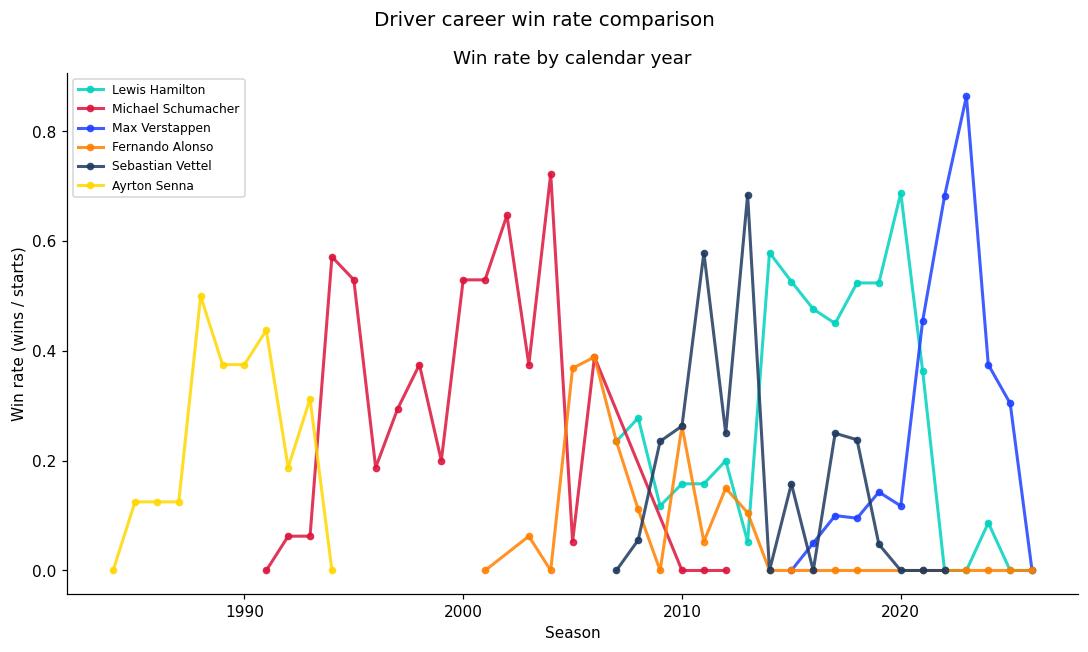

In [116]:
# Career win rate by calendar year
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    ax.plot(sd['year'], sd['win_rate'], 'o-', label=drv,
            color=c, linewidth=2, markersize=4, alpha=0.85)

ax.set_title('Win rate by calendar year')
ax.set_xlabel('Season')
ax.set_ylabel('Win rate (wins / starts)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


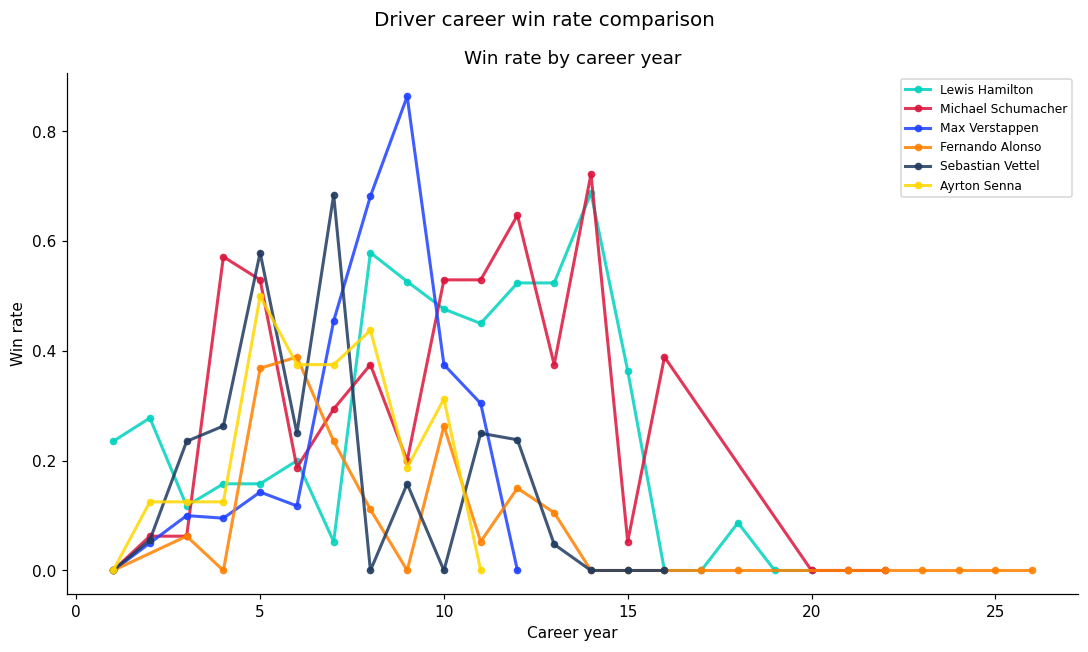

Best 3-consecutive-season average win rate:
  Lewis Hamilton        : 0.578  (peak starting 2018)
  Michael Schumacher    : 0.581  (peak starting 2002)
  Max Verstappen        : 0.667  (peak starting 2021)
  Fernando Alonso       : 0.331  (peak starting 2005)
  Sebastian Vettel      : 0.504  (peak starting 2011)
  Ayrton Senna          : 0.417  (peak starting 1988)


In [117]:
# Career win rate by career year 
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Driver career win rate comparison', fontsize=13)

for drv in LEGENDS:
    sd = season_stats[season_stats['driver'] == drv].sort_values('year')
    c  = COLORS_DRV[drv]
    ax.plot(sd['career_year'], sd['win_rate'], 'o-', label=drv,
            color=c, linewidth=2, markersize=4, alpha=0.85)

ax.set_title('Win rate by career year')
ax.set_xlabel('Career year')
ax.set_ylabel('Win rate')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Best 3-season peak 
print("Best 3-consecutive-season average win rate:")
for drv in LEGENDS:
    ss = season_stats[season_stats['driver'] == drv].sort_values('year')
    if len(ss) < 3: continue
    best_val = max(ss.iloc[i:i+3]['win_rate'].mean() for i in range(len(ss)-2))
    best_start = ss.iloc[
        [ss.iloc[i:i+3]['win_rate'].mean() for i in range(len(ss)-2)].index(best_val)
    ]['year']
    print(f"  {drv:<22}: {best_val:.3f}  (peak starting {int(best_start)})")


In [118]:
# Driver Head-to-Head Comparison Brocesed Era

year_range = (2013, 2016)
team_races = base[base['year'].between(*year_range)].copy()

ham = team_races[team_races['driver'] == 'Lewis Hamilton'][['raceId','constructorId','positionOrder']]
rsb = team_races[team_races['driver'] == 'Nico Rosberg'][['raceId','constructorId','positionOrder']]

h2h = ham.merge(rsb, on=['raceId','constructorId'], suffixes=('_ham','_rsb')).dropna()
ham_wins = (h2h['positionOrder_ham'] < h2h['positionOrder_rsb']).sum()
rsb_wins = (h2h['positionOrder_ham'] > h2h['positionOrder_rsb']).sum()

print(f"Hamilton vs Rosberg (Mercedes, {year_range[0]}–{year_range[1]}):")
print(f"  Hamilton ahead: {ham_wins} races")
print(f"  Rosberg ahead:   {rsb_wins} races")
print(f"  Hamilton win rate: {ham_wins/(ham_wins+rsb_wins)*100:.1f}%")
print()


Hamilton vs Rosberg (Mercedes, 2013–2016):
  Hamilton ahead: 45 races
  Rosberg ahead:   33 races
  Hamilton win rate: 57.7%



---
## 9. Lap time trends <a id='lap-times'></a>

**Question:** Are F1 cars genuinely getting faster, and how does the field spread change over time?

**Safety car lap removal:** We remove any lap that is more than 50% slower than the  
race median — these are almost always safety car laps or slow out-laps after a pit stop.  
Without this step, our averages would be distorted.

We then **normalise** lap times to a 1996 baseline so we can compare across circuits  
(Monaco laps are ~73s; Monza laps are ~80s — raw times can't be directly compared).


In [119]:
# Load lap times, merge with race data, and filter outliers (80–150% of race median)
lt = lap_times.merge(races[['raceId', 'year', 'circuitId']], on='raceId')
race_med = lt.groupby('raceId')['milliseconds'].median()
lt_clean = lt[lt['milliseconds'].between(
    race_med.loc[lt['raceId']].values * 0.8,
    race_med.loc[lt['raceId']].values * 1.5
)].copy()

removed = len(lt) - len(lt_clean)
print(f"Laps removed: {removed:,} ({removed/len(lt)*100:.1f}%)")

# Aggregate to annual median lap time
annual = (lt_clean
    .groupby(['raceId', 'year'])['milliseconds'].median()
    .reset_index(name='median_lap_ms')
    .groupby('year')['median_lap_ms'].median()
    .reset_index(name='median_lap_ms'))

# Normalize to 1996 baseline
baseline_1996 = annual[annual['year'] == 1996]['median_lap_ms'].iloc[0]
annual['normalised'] = annual['median_lap_ms'] / baseline_1996

fastest = annual.loc[annual['normalised'].idxmin(), 'year']
slowest = annual.loc[annual['normalised'].idxmax(), 'year']
print(f"Baseline (1996): {baseline_1996/1000:.2f}s | Fastest: {fastest} | Slowest: {slowest}")


Laps removed: 12,604 (2.0%)
Baseline (1996): 92.79s | Fastest: 2004 | Slowest: 2011


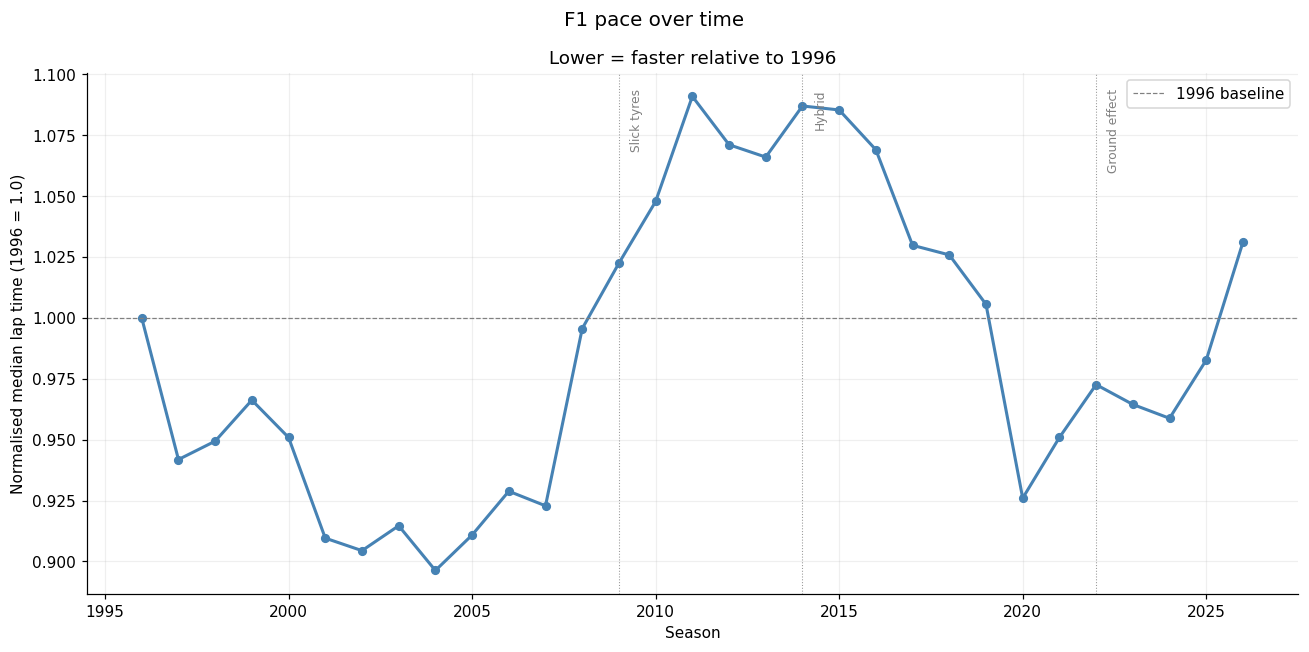

Lap generally go through waves, with periods of decreasing lap times as the era progresses
then slows are new regulations are introduced


In [127]:
# Normalized lap time trend over time
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('F1 pace over time', fontsize=13)

ax.plot(annual['year'], annual['normalised'], 'o-', color='steelblue',
        linewidth=2, markersize=5)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='1996 baseline')

# Mark major regulation changes
for yr, label in [(2009, 'Slick tyres'), (2014, 'Hybrid'), (2022, 'Ground effect')]:
    ax.axvline(yr, color='gray', linewidth=0.7, linestyle=':', alpha=0.8)
    ax.text(yr + 0.3, annual['normalised'].max() + 0.003,
            label, fontsize=8, color='gray', rotation=90, va='top')

ax.set_xlabel('Season')
ax.set_ylabel('Normalised median lap time (1996 = 1.0)')
ax.set_title('Lower = faster relative to 1996')
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

print("Lap generally go through waves, with periods of decreasing lap times as the era progresses")
print("then slows are new regulations are introduced")


---
## 10. Qualifying improvement (Q1→Q3) <a id='qualifying'></a>

**Question:** How much do drivers improve their lap time across Q1, Q2, and Q3?

A **negative delta** means the driver got faster (improved). We expect improvement  
because: the track rubbered in (more grip), the driver learned the track, and  
they try progressively harder as the session goes on.


In [121]:
# Convert time strings to seconds
def parse_time(t):
    if pd.isna(t) or str(t) in ('\\N', ''):
        return np.nan
    try:
        parts = str(t).split(':')
        if len(parts) == 2:
            return float(parts[0]) * 60 + float(parts[1])
        return float(t)
    except:
        return np.nan

qualifying['q1_s'] = qualifying['q1'].apply(parse_time)
qualifying['q2_s'] = qualifying['q2'].apply(parse_time)
qualifying['q3_s'] = qualifying['q3'].apply(parse_time)

# Best time = fastest across all sessions they participated in
qualifying['q_best_s'] = qualifying[['q1_s', 'q2_s', 'q3_s']].min(axis=1)

# Calculate improvements between sessions
# Negative = improved (faster); positive = got slower
qualifying['q1_to_q2'] = qualifying['q2_s'] - qualifying['q1_s']
qualifying['q2_to_q3'] = qualifying['q3_s'] - qualifying['q2_s']
qualifying['q1_to_q3'] = qualifying['q3_s'] - qualifying['q1_s']  

# keep rows with all three session times
q_all = qualifying.dropna(subset=['q1_s', 'q2_s', 'q3_s']).copy()
q_all = q_all.merge(races[['raceId', 'year']], on='raceId')
q_all = q_all.merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
q_all['driver'] = q_all['forename'] + ' ' + q_all['surname']

print(f"Qualifying sessions with all 3 sessions: {len(q_all):,}")
print(f"Overall average Q1→Q3 improvement: {q_all['q1_to_q3'].mean():.3f} seconds")
print("(Negative = faster in Q3 than Q1)")


Qualifying sessions with all 3 sessions: 3,893
Overall average Q1→Q3 improvement: -0.534 seconds
(Negative = faster in Q3 than Q1)


---
## 11. Lap 1 analysis <a id='lap1'></a>

**Question:** What happens on the first lap — how much does the field reshuffle,  
and which grid positions carry the most crash risk?

The `lap_times` table records each driver's position at the end of every lap.  
Lap 1 shows us where everyone ended up after the standing start and first corner.

We define a **lap 1 DNF** as any retirement where a driver completed 1 lap or fewer.


In [122]:
# Extract lap 1 positions
lap1 = (lap_times[lap_times['lap'] == 1][['raceId', 'driverId', 'position']]
        .rename(columns={'position': 'lap1_pos'}))

# Join onto our base table
df_l1 = base.merge(lap1, on=['raceId', 'driverId'], how='left')
df_l1['lap1_pos']  = pd.to_numeric(df_l1['lap1_pos'], errors='coerce')
df_l1['laps']      = pd.to_numeric(results.set_index('resultId').reindex(
                      df_l1.index, fill_value=np.nan).get('laps', np.nan), errors='coerce')


laps_col = pd.to_numeric(results['laps'], errors='coerce')
results2  = results.copy()
results2['laps_num'] = laps_col
df_l1 = df_l1.merge(results2[['raceId','driverId','laps']].assign(
    laps=pd.to_numeric(results2['laps'], errors='coerce')),
    on=['raceId','driverId'], how='left', suffixes=('','_r'))

df_l1['lap1_gain'] = df_l1['grid'] - df_l1['lap1_pos']   # positive = gain position
df_l1['lap1_dnf']  = ((df_l1['laps_r'] <= 1) & (df_l1['dnf'] == 1)).astype(int)

print(f"Drivers with lap 1 position data: {df_l1['lap1_pos'].notna().sum():,}")
print(f"Lap 1 DNF rate (all time):  {df_l1['lap1_dnf'].mean()*100:.2f}%")
print(f"Lap 1 DNF rate (2010+):     {df_l1[df_l1['year']>=2010]['lap1_dnf'].mean()*100:.2f}%")
print()
print(f"% of drivers who gained places on lap 1: {(df_l1['lap1_gain']>0).mean()*100:.1f}%")
print(f"% who lost places:                       {(df_l1['lap1_gain']<0).mean()*100:.1f}%")
print(f"% who held their grid position:           {(df_l1['lap1_gain']==0).mean()*100:.1f}%")


Drivers with lap 1 position data: 11,474
Lap 1 DNF rate (all time):  4.98%
Lap 1 DNF rate (2010+):     3.59%

% of drivers who gained places on lap 1: 21.0%
% who lost places:                       12.5%
% who held their grid position:           11.3%


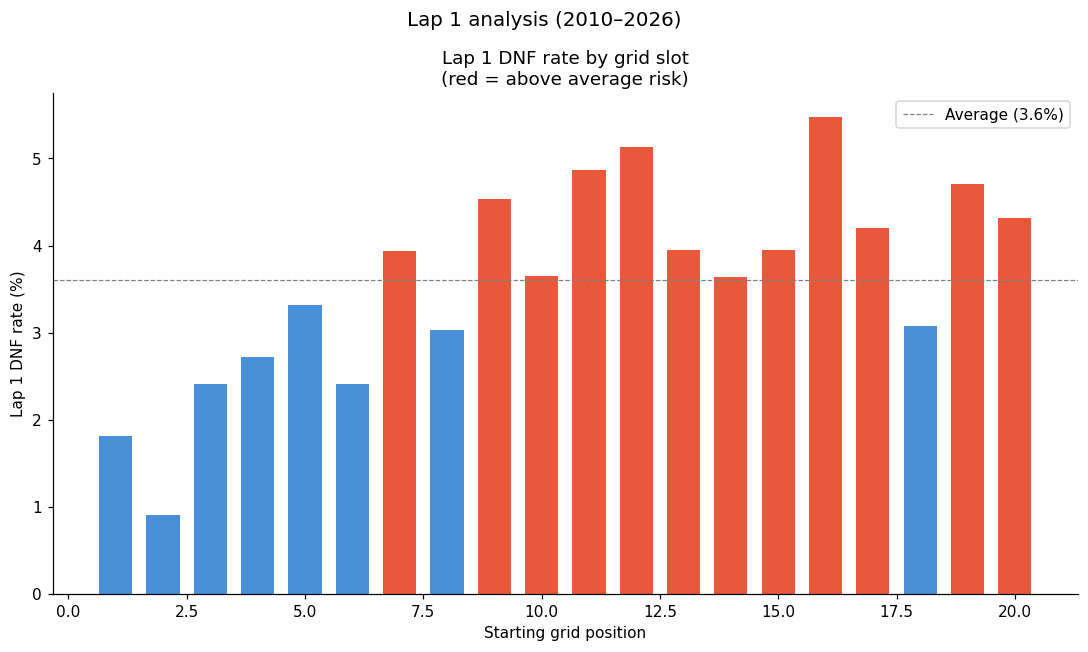

In [123]:
# Chart: grid position → lap 1 DNF risk 
df_l1_mod = df_l1[df_l1['year'] >= 2010].copy()
grid_risk  = (df_l1_mod[df_l1_mod['grid'] <= 20]
              .groupby('grid')['lap1_dnf'].mean() * 100)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Lap 1 analysis (2010–2026)', fontsize=13)

# DNF rate by grid slot
ax.bar(grid_risk.index, grid_risk.values,
            color=['#E8593C' if v > grid_risk.mean() else '#4A90D9' for v in grid_risk.values],
            width=0.7)
ax.axhline(grid_risk.mean(), color='gray', linewidth=0.8, linestyle='--',
                label=f'Average ({grid_risk.mean():.1f}%)')
ax.set_xlabel('Starting grid position')
ax.set_ylabel('Lap 1 DNF rate (%)')
ax.set_title('Lap 1 DNF rate by grid slot\n(red = above average risk)')
ax.legend()


plt.tight_layout()
plt.show()



---
## 12. Summary <a id='summary'></a>

| Section | Method | Key finding |
|---------|--------|-------------|
| 3. Pit stop strategy | Box plot + bar chart | 2-stop strategy shows the best average position change; 1-stop and 3+ stops are slightly worse. |
| 4. Circuit clustering | KMeans | Circuits fall into 3 groups based on pit stops, overtaking difficulty, and DNF rate. |
| 5. Grid vs finish | Pearson correlation | r = 0.45 — moderate effect. Grid matters more in modern F1 (r = 0.69 in 2023+). |
| 6. Race result predictor | Ridge + Random Forest | MAE ≈ 3.5 places. Grid position (47%) is the most important feature. |
| 7. Constructor standings | Line chart + bump chart | Red Bull and Mercedes dominated different eras (2010–13 and 2014–21). |
| 8. Driver careers | Win rate + H2H | Verstappen's 2021–23 peak win rate (66.7%) is the highest 3-season stretch on record. |
| 9. Lap time trends | Normalised medians | . |
| 10. Qualifying | Q1→Q3 delta | Average improvement of 0.53s from Q1 to Q3. Pérez peaks in Q2 most often. |
| 11. Lap 1 analysis | DNF rate | 4.98% all-time lap 1 DNF rate. 2010-2026 is 3.59% |


*Dataset: [Kaggle F1 Race Data (1950–2026)](https://www.kaggle.com/datasets/jtrotman/formula-1-race-data/data)*
